In [ ]:
#Task 1 — Data Loading, Merging & Deep Exploration
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced plots
import seaborn as sns

# Import datetime related functions
from datetime import datetime

# Display all columns of dataframe
pd.set_option('display.max_columns', None)

In [ ]:
# Load the Superstore CSV file into a pandas dataframe
df = pd.read_csv("train.csv")

# Display first 5 rows to understand dataset structure
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
# Print number of rows and columns
# Rows represent sales transactions
# Columns represent features like product, sales, dates etc.
print("Dataset Shape:", df.shape)

Dataset Shape: (9800, 18)


In [ ]:
# Display column names, data types and missing values
# Helps identify incorrect data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
# Convert Order Date column into datetime format
# dayfirst=True tells pandas that first value is day, second value is month
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

# Convert Ship Date column into datetime format
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

# Check the converted data types
df[['Order Date','Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
# Extract year from Order Date
# Helps analyze yearly sales growth
df['Year'] = df['Order Date'].dt.year

df[['Order Date','Year']].head()

,Order Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [ ]:
# Extract month number from Order Date
# Used for seasonal analysis
df['Month'] = df['Order Date'].dt.month

# Extract month name
df['Month_Name'] = df['Order Date'].dt.month_name()

df[['Order Date','Month','Month_Name']].head()

,Order Date,Month,Month_Name
0,2017-11-08,11,November
1,2017-11-08,11,November
2,2017-06-12,6,June
3,2016-10-11,10,October
4,2016-10-11,10,October


In [ ]:
# Extract week number from order date
# Useful for weekly sales forecasting
df['Week_Number'] = df['Order Date'].dt.isocalendar().week

df[['Order Date','Week_Number']].head()

,Order Date,Week_Number
0,2017-11-08,45
1,2017-11-08,45
2,2017-06-12,24
3,2016-10-11,41
4,2016-10-11,41


In [ ]:
# Extract day of week
# Monday = 0 and Sunday = 6
df['Day_of_Week'] = df['Order Date'].dt.day_name()

df[['Order Date','Day_of_Week']].head()

,Order Date,Day_of_Week
0,2017-11-08,Wednesday
1,2017-11-08,Wednesday
2,2017-06-12,Monday
3,2016-10-11,Tuesday
4,2016-10-11,Tuesday


In [ ]:
# Extract quarter from order date
# Q1,Q2,Q3,Q4 helps identify seasonal patterns
df['Quarter'] = df['Order Date'].dt.quarter

df[['Order Date','Quarter']].head()

,Order Date,Quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


In [ ]:
# Create function to classify months into seasons

def get_season(month):

    # Winter months
    if month in [12,1,2]:
        return "Winter"

    # Spring months
    elif month in [3,4,5]:
        return "Spring"

    # Summer months
    elif month in [6,7,8]:
        return "Summer"

    # Autumn months
    else:
        return "Autumn"


# Apply season function
df['Season'] = df['Month'].apply(get_season)

# Check result
df[['Month','Season']].head()

,Month,Season
0,11,Autumn
1,11,Autumn
2,6,Summer
3,10,Autumn
4,10,Autumn


In [ ]:
# Count missing values in every column
missing_values = df.isnull().sum()

missing_values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
# Display datatype of every column
# Used to find incorrect formats
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
# Group sales by date
# Creates daily sales time series

daily_sales = df.groupby('Order Date')['Sales'].sum()

daily_sales.head()

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


In [ ]:
# Convert daily sales into weekly sales totals

weekly_sales = daily_sales.resample('W').sum()

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [ ]:
# Convert daily sales into monthly sales totals

monthly_sales = daily_sales.resample('M').sum()

monthly_sales.head()

/tmp/ipykernel_869/3190264388.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample('M').sum()


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
# Calculate total sales by category

category_sales = df.groupby('Category')['Sales'].sum()

# Sort categories by revenue
category_sales = category_sales.sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


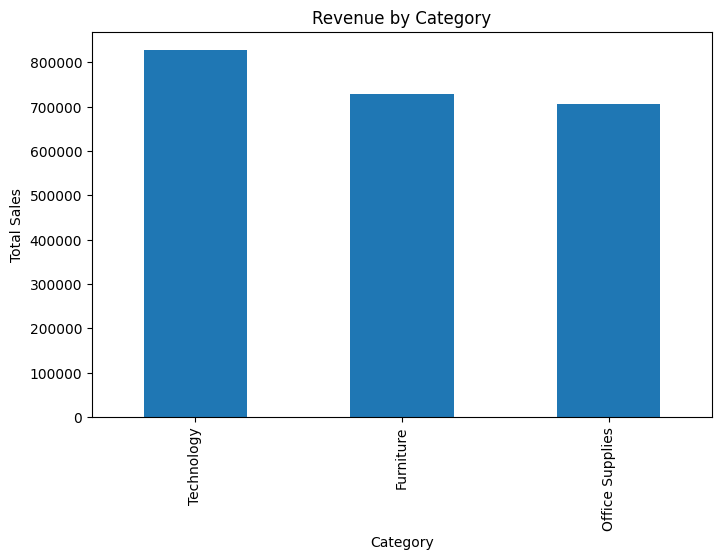

In [ ]:
# Plot category revenue

category_sales.plot(
    kind='bar',
    figsize=(8,5),
    title="Revenue by Category"
)

plt.ylabel("Total Sales")
plt.show()

In [ ]:
# Calculate yearly sales by region

region_year_sales = (
    df.groupby(['Region','Year'])['Sales']
    .sum()
    .reset_index()
)

region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


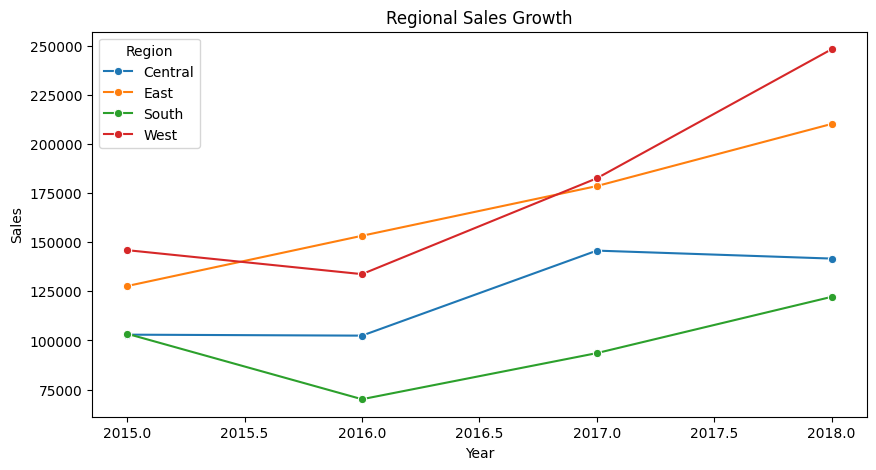

In [ ]:
# Plot yearly growth for every region

plt.figure(figsize=(10,5))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth")
plt.show()

In [ ]:
# Calculate delivery time

df['Shipping_Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days


# Average shipping days
df['Shipping_Days'].mean()

np.float64(3.9611224489795918)

In [ ]:
# Calculate monthly sales pattern

monthly_pattern = (
    df.groupby(['Year','Month_Name'])['Sales']
    .sum()
)

monthly_pattern

Year  Month_Name
2015  April          27906.8550
      August         27117.5365
      December       68167.0585
      February        4519.8920
      January        14205.7070
      July           33781.5430
      June           34322.9356
      March          55205.7970
      May            23644.3030
      November       77907.6607
      October        31453.3930
      September      81623.5268
2016  April          34154.4685
      August         36818.3422
      December       74543.6012
      February       11951.4110
      January        18066.9576
      July           28608.2590
      June           23599.3740
      March          32339.3184
      May            29959.5305
      November       75249.3995
      October        31011.7375
      September      63133.6060
2017  April          38679.7670
      August         30542.2003
      December       95739.1210
      February       22978.8150
      January        18542.4910
      July           38320.7830
      June           39724.4860
      March          51165.0590
      May            56656.9080
      November       79066.4958
      October        59583.0330
      September      69193.3909
2018  April          35541.9101
      August         62837.8480
      December       83030.3888
      February       19920.9974
      January        43476.4740
      July           44825.1040
      June           48190.7277
      March          58863.4128
      May            43825.9822
      November      117938.1550
      October        77448.1312
      September      86152.8880
Name: Sales, dtype: float64

In [ ]:
# Month-wise average sales across years

seasonality = (
    df.groupby('Month_Name')['Sales']
    .mean()
)

seasonality.sort_values(ascending=False)

,Sales
Month_Name,
March,290.549393
January,257.627403
October,246.596162
November,241.657496
December,232.619515
August,227.007110
September,221.642106
May,212.533412
June,211.052856


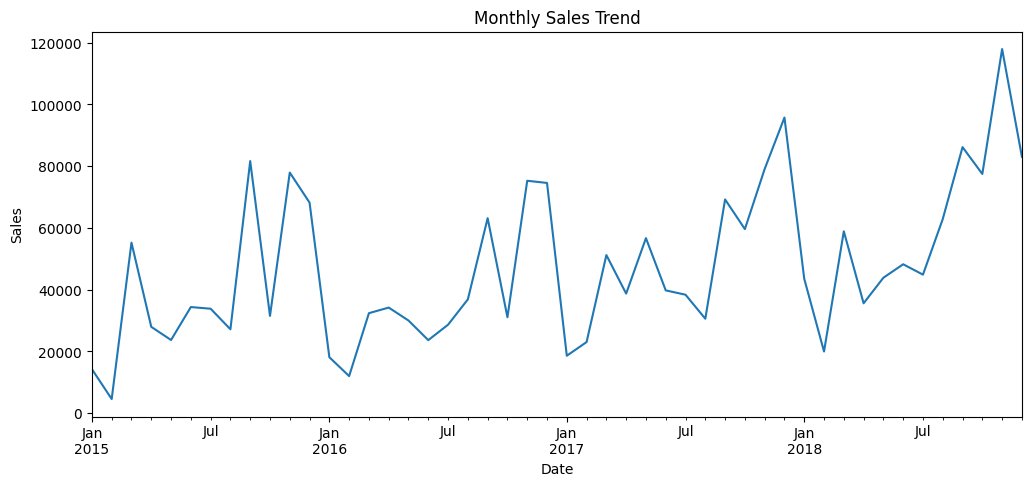

In [ ]:
#Task 2 — Time Series Analysis & Decomposition
# Plot monthly sales trend

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
# Import seasonal decomposition method

from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# Perform decomposition
# Period=12 means yearly seasonality because data is monthly

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

# Store components

trend = decomposition.trend

seasonal = decomposition.seasonal

residual = decomposition.resid

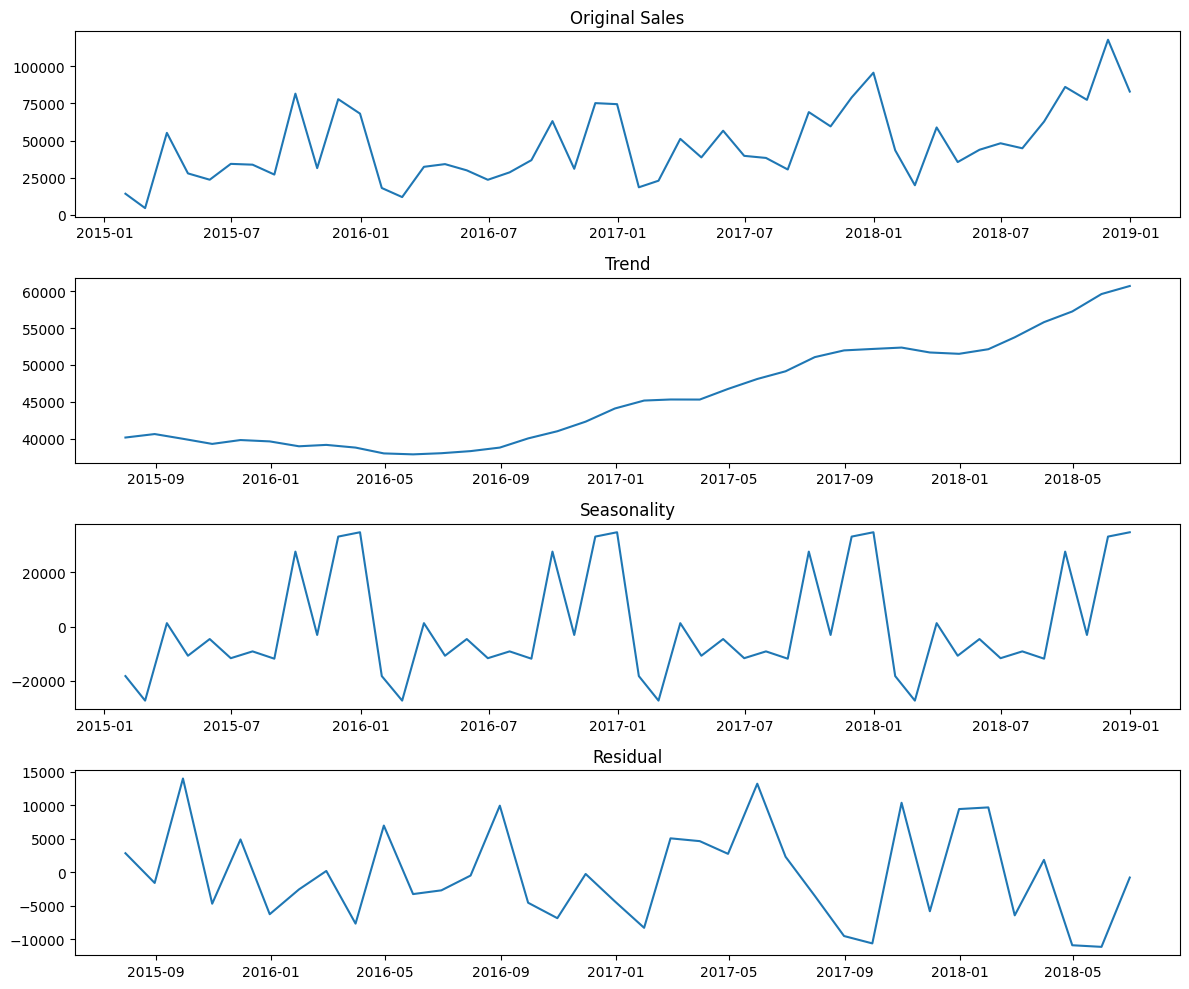

In [ ]:
# Plot trend, seasonality and residual components

plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(monthly_sales)
plt.title("Original Sales")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonality")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()

plt.show()

In [ ]:
# Import Augmented Dickey Fuller test

from statsmodels.tsa.stattools import adfuller


# Run ADF test

result = adfuller(monthly_sales.dropna())


print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


In [ ]:
# Check p-value

if result[1] <= 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary")

Series is stationary


In [ ]:
# Difference removes trend from time series

monthly_diff = monthly_sales.diff()

# Remove first missing value

monthly_diff = monthly_diff.dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


In [ ]:
# Run ADF test after differencing

result_diff = adfuller(monthly_diff)


print("ADF Statistic:", result_diff[0])

print("p-value:", result_diff[1])

ADF Statistic: -8.727061830353264
p-value: 3.2669175472797e-14


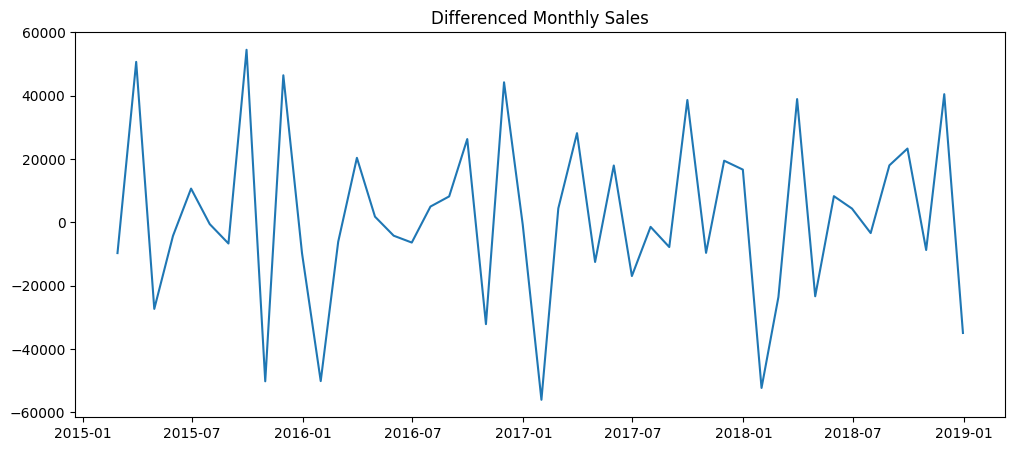

In [ ]:
# Plot stationary series

plt.figure(figsize=(12,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.show()

In [ ]:
#Task 3 — Sales Forecasting Using 3 Different Models
#Model 1 — SARIMA (Statistical Forecasting)
# Install statsmodels library if not installed
!pip install statsmodels

# Import SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import numpy for calculations
import numpy as np

In [ ]:
# Convert monthly sales into dataframe
# SARIMA requires continuous time series format

sarima_data = monthly_sales.to_frame()

# Rename sales column
sarima_data.columns = ['Sales']

# Display data
sarima_data.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
# Use last 3 months as testing data
# Remaining data will be used for training

train = sarima_data.iloc[:-3]

test = sarima_data.iloc[-3:]


print("Training Data:", train.shape)

print("Testing Data:", test.shape)

Training Data: (45, 1)
Testing Data: (3, 1)


In [ ]:
# SARIMA parameters:
#
# p = autoregressive order
# d = differencing order
# q = moving average order
#
# P,D,Q = seasonal parameters
# m = seasonal period
#
# Monthly sales has yearly seasonality:
# Therefore m = 12

sarima_model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)


# Train model
sarima_result = sarima_model.fit()


# Display model summary
sarima_result.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Thu, 09 Jul 2026   AIC                            705.958
Time:                                    11:55:01   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177     -5.084      0.000      -1.245      -0.552
ar.S.L12       0.0621      0.540      0.115      0.908      -0.996       1.120
ma.S.L12      -0.4852      0.620     -0.783      0.434      -1.700       0.730
sigma2      1.822e+08   1.54e-09   1.18e+17      0.000    1.82e+08    1.82e+08
===================================================================================
Ljung-Box (L1) (Q):                   2.47   Jarque-Bera (JB):                 0.73
Prob(Q):                              0.12   Prob(JB):                         0.69
Heteroskedasticity (H):               1.35   Skew:                             0.14
Prob(H) (two-sided):                  0.62   Kurtosis:                         2.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.11e+33. Standard errors may be unstable.
"""

In [ ]:
# Forecast next 3 months

sarima_forecast = sarima_result.get_forecast(
    steps=3
)


# Get predicted values

sarima_pred = sarima_forecast.predicted_mean


# Confidence interval

sarima_conf = sarima_forecast.conf_int()


print(sarima_pred)

2018-10-31    66177.602475
2018-11-30    92049.249682
2018-12-31    99965.168727
Freq: ME, Name: predicted_mean, dtype: float64


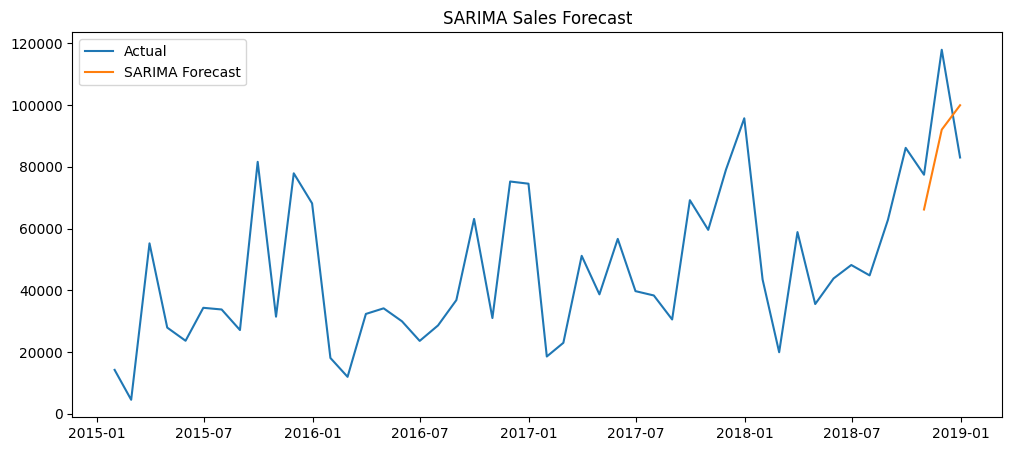

In [ ]:
# Plot actual and predicted sales

plt.figure(figsize=(12,5))

plt.plot(
    sarima_data.index,
    sarima_data['Sales'],
    label="Actual"
)


plt.plot(
    sarima_pred.index,
    sarima_pred,
    label="SARIMA Forecast"
)


plt.title("SARIMA Sales Forecast")

plt.legend()

plt.show()

In [ ]:
#Model 2 — Facebook Prophet
# Install prophet library

!pip install prophet

In [ ]:
# Import Prophet model

from prophet import Prophet

In [ ]:
# Prophet requires:
# ds = date column
# y = target value


prophet_df = monthly_sales.reset_index()


# Rename columns

prophet_df.columns = [
    'ds',
    'y'
]


prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# Create Prophet model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False
)


# Train model

prophet_model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Create future dataframe for next 3 months

future = prophet_model.make_future_dataframe(
    periods=3,
    freq='M'
)


# Generate forecast

prophet_forecast = prophet_model.predict(
    future
)


# Display last 3 predictions

prophet_forecast[
    ['ds','yhat']
].tail(3)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat
48,2019-01-31,42990.532194
49,2019-02-28,31248.159913
50,2019-03-31,81267.007763


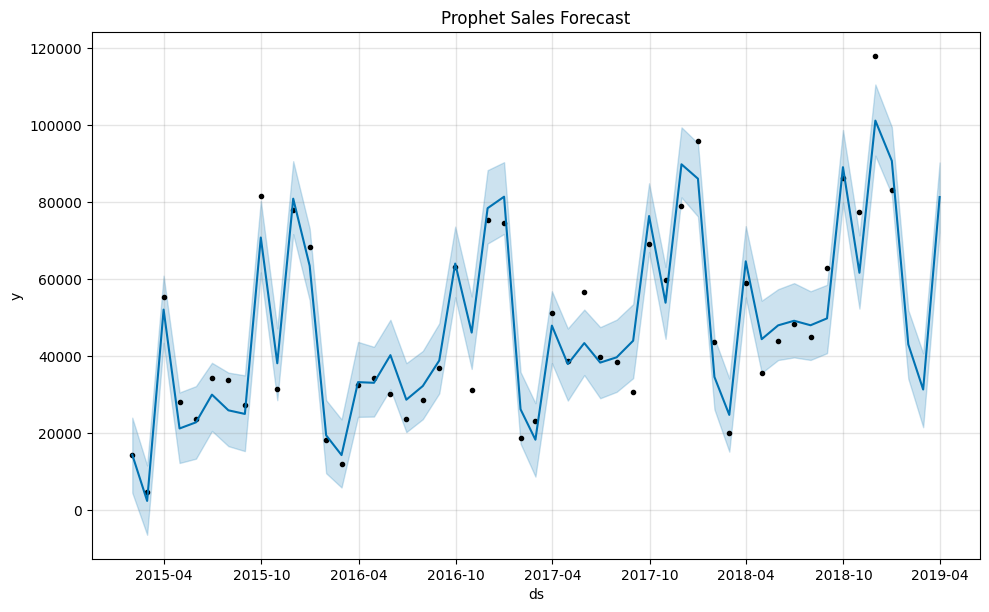

In [ ]:
# Prophet built-in forecast plot

prophet_model.plot(
    prophet_forecast
)

plt.title(
    "Prophet Sales Forecast"
)

plt.show()

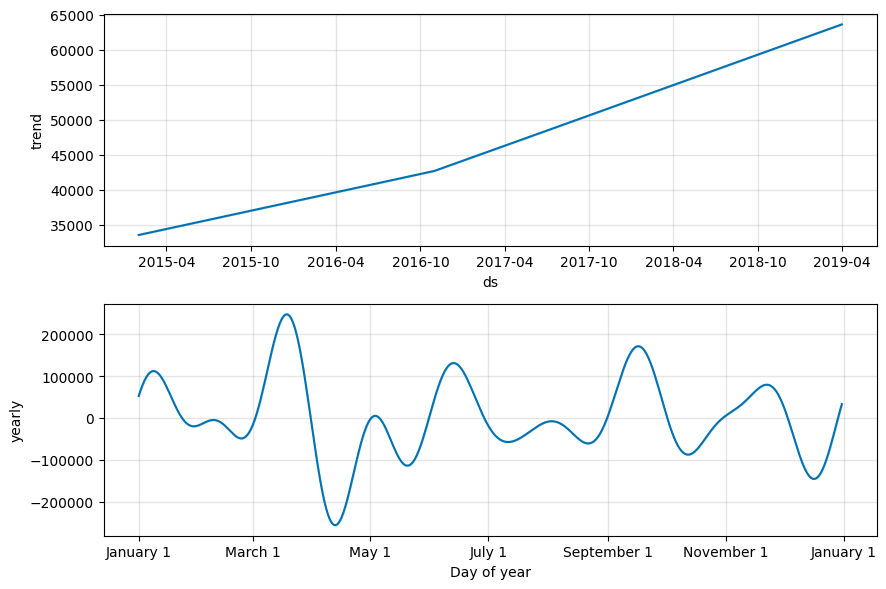

In [ ]:
# Display trend and seasonality

prophet_model.plot_components(
    prophet_forecast
)

plt.show()

In [ ]:
#Model 3 — XGBoost Time Series
# Import XGBoost

from xgboost import XGBRegressor

# Import dataframe tools

import pandas as pd

In [ ]:
# Convert series into dataframe

xgb_df = monthly_sales.to_frame()

xgb_df.columns=['Sales']


# Create lag features

xgb_df['Lag1'] = xgb_df['Sales'].shift(1)

xgb_df['Lag2'] = xgb_df['Sales'].shift(2)

xgb_df['Lag3'] = xgb_df['Sales'].shift(3)


# Create rolling mean

xgb_df['Rolling_Mean_3'] = (
    xgb_df['Sales']
    .rolling(3)
    .mean()
)


# Extract month

xgb_df['Month'] = xgb_df.index.month


# Extract quarter

xgb_df['Quarter'] = xgb_df.index.quarter


# Remove missing rows

xgb_df.dropna(inplace=True)


xgb_df.head()

,Sales,Lag1,Lag2,Lag3,Rolling_Mean_3,Month,Quarter
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [ ]:
# Input features

X = xgb_df.drop(
    'Sales',
    axis=1
)


# Target variable

y = xgb_df['Sales']


# Train-test split

X_train = X.iloc[:-3]

X_test = X.iloc[-3:]


y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [ ]:
# Create XGBoost regression model

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)


# Train model

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict testing period

xgb_pred = xgb_model.predict(
    X_test
)


xgb_pred

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

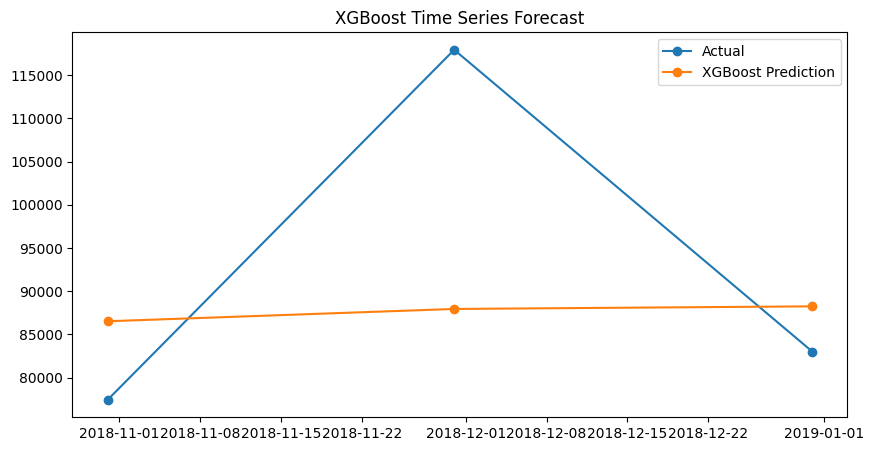

In [ ]:
# Compare actual and predicted

plt.figure(figsize=(10,5))


plt.plot(
    y_test.index,
    y_test,
    marker='o',
    label="Actual"
)


plt.plot(
    y_test.index,
    xgb_pred,
    marker='o',
    label="XGBoost Prediction"
)


plt.title(
    "XGBoost Time Series Forecast"
)


plt.legend()

plt.show()

In [ ]:
#Model Evaluation
# Function to calculate MAE RMSE and MAPE

def evaluate(actual, prediction):

    mae = mean_absolute_error(
        actual,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction
        )
    )

    mape = np.mean(
        np.abs(
            (actual-prediction)/actual
        )
    )*100


    return mae, rmse, mape

In [ ]:
# Get Prophet predictions for the last 3 months
# These months are the same testing period used for SARIMA

prophet_test_pred = (
    prophet_forecast['yhat']
    .tail(3)
    .values
)


# Calculate Prophet error metrics

prophet_mae, prophet_rmse, prophet_mape = evaluate(
    test['Sales'].values,
    prophet_test_pred
)


# Display Prophet performance

print("Prophet MAE:", prophet_mae)

print("Prophet RMSE:", prophet_rmse)

print("Prophet MAPE:", prophet_mape)

Prophet MAE: 40970.32504309633
Prophet RMSE: 53868.94866261766
Prophet MAPE: 40.039864949122084


In [ ]:
# SARIMA evaluation

sarima_mae, sarima_rmse, sarima_mape = evaluate(
    test['Sales'],
    sarima_pred
)


# XGBoost evaluation

xgb_mae, xgb_rmse, xgb_mape = evaluate(
    y_test,
    xgb_pred
)



print(
"SARIMA:",
sarima_mae,
sarima_rmse,
sarima_mape
)


print(
"XGBoost:",
xgb_mae,
xgb_rmse,
xgb_mape
)

SARIMA: 18031.404656492246 19009.182057244216 18.96649804808188
XGBoost: 14763.810624999998 18337.412565486276 14.481277237255794


In [ ]:
comparison = pd.DataFrame({

"Model":[
"SARIMA",
"Prophet",
"XGBoost"
],

"MAE":[
sarima_mae,
prophet_mae,
xgb_mae
],

"RMSE":[
sarima_rmse,
prophet_rmse,
xgb_rmse
],

"MAPE":[
sarima_mape,
prophet_mape,
xgb_mape
],

"Forecast Month 1":[
sarima_pred.iloc[0],
prophet_forecast['yhat'].tail(3).iloc[0],
xgb_pred[0]
],

"Forecast Month 2":[
sarima_pred.iloc[1],
prophet_forecast['yhat'].tail(3).iloc[1],
xgb_pred[1]
],

"Forecast Month 3":[
sarima_pred.iloc[2],
prophet_forecast['yhat'].tail(3).iloc[2],
xgb_pred[2]
]

})


comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404656,19009.182057,18.966498,66177.602475,92049.249682,99965.168727
1,Prophet,40970.325043,53868.948663,40.039865,42990.532194,31248.159913,81267.007763
2,XGBoost,14763.810625,18337.412565,14.481277,86530.492188,87955.140625,88256.445312


In [ ]:
# Identify best model based on evaluation metrics

# Rank models (lower value = better)
comparison["MAE Rank"] = comparison["MAE"].rank()
comparison["RMSE Rank"] = comparison["RMSE"].rank()
comparison["MAPE Rank"] = comparison["MAPE"].rank()

# Calculate overall score
comparison["Overall Score"] = (
    comparison["MAE Rank"] +
    comparison["RMSE Rank"] +
    comparison["MAPE Rank"]
)

# Select best model
best_model = comparison.loc[
    comparison["Overall Score"].idxmin(),
    "Model"
]

print("===== Production Model Recommendation =====")
print(f"Recommended Model: {best_model}")

# Display reason based on metrics
best_row = comparison[comparison["Model"] == best_model].iloc[0]

print("\nPerformance Metrics:")
print(f"MAE  : {best_row['MAE']:.2f}")
print(f"RMSE : {best_row['RMSE']:.2f}")
print(f"MAPE : {best_row['MAPE']:.2f}%")

print("\nReason:")
print(
    f"{best_model} is selected for production because it achieved "
    f"the lowest combined forecasting error across MAE, RMSE, and MAPE. "
    f"It provides the most accurate and reliable sales predictions "
    f"among the evaluated models."
)

# Show comparison table with ranking
comparison.sort_values("Overall Score")

===== Production Model Recommendation =====
Recommended Model: XGBoost

Performance Metrics:
MAE  : 14763.81
RMSE : 18337.41
MAPE : 14.48%

Reason:
XGBoost is selected for production because it achieved the lowest combined forecasting error across MAE, RMSE, and MAPE. It provides the most accurate and reliable sales predictions among the evaluated models.


,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3,MAE Rank,RMSE Rank,MAPE Rank,Overall Score
2,XGBoost,14763.810625,18337.412565,14.481277,86530.492188,87955.140625,88256.445312,1.0,1.0,1.0,3.0
0,SARIMA,18031.404656,19009.182057,18.966498,66177.602475,92049.249682,99965.168727,2.0,2.0,2.0,6.0
1,Prophet,40970.325043,53868.948663,40.039865,42990.532194,31248.159913,81267.007763,3.0,3.0,3.0,9.0


/tmp/ipykernel_869/2618442269.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = temp.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
/tmp/ipykernel_869/2618442269.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = temp.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
/tmp/ipykernel_869/2618442269.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = temp.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
/tmp/ipykernel_869/2618442269.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = temp.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
/tmp/ipykernel_869/2618442269.py:28: FutureWarning: 'M' is deprecated and will b

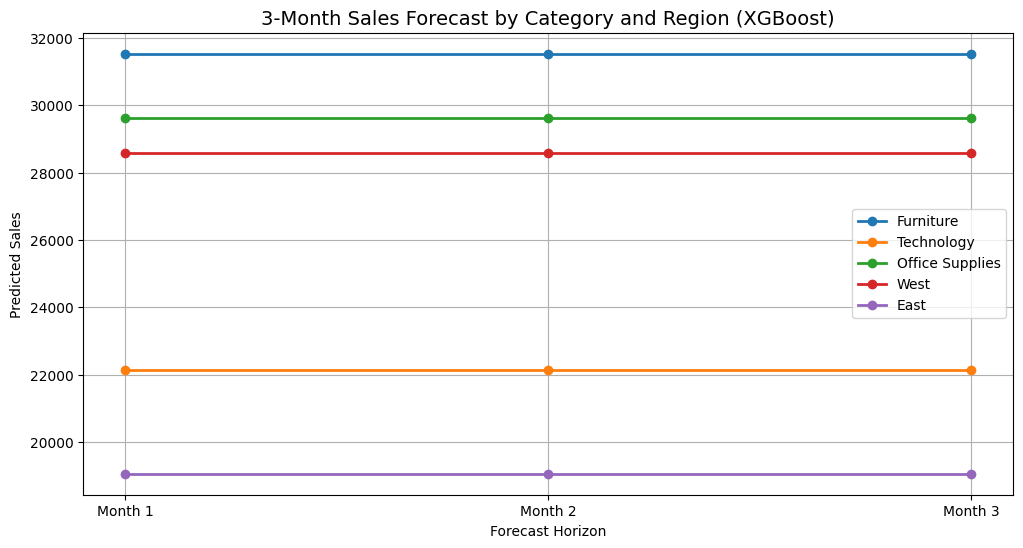


Expected Growth by Segment
           Segment  Growth
0        Furniture     0.0
1       Technology     0.0
2  Office Supplies     0.0
3             West     0.0
4             East     0.0

Strongest Upcoming Growth
Segment : Furniture
Growth  : 0.00

Conclusion:
According to the XGBoost forecasting model, 'Furniture' is expected to show the strongest sales growth over the next three months.


In [ ]:
# ==========================================
# Task 4: Category & Region Level Forecasting
# Best Model: XGBoost
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

segments = {
    "Furniture": ("Category", "Furniture"),
    "Technology": ("Category", "Technology"),
    "Office Supplies": ("Category", "Office Supplies"),
    "West": ("Region", "West"),
    "East": ("Region", "East")
}

forecast_results = {}

for name, (column, value) in segments.items():

    temp = df[df[column] == value].copy()

    monthly = temp.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

    monthly["Month"] = np.arange(len(monthly))

    X = monthly[["Month"]]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X, y)

    future_months = np.arange(len(monthly), len(monthly)+3).reshape(-1,1)

    pred = model.predict(future_months)

    forecast_results[name] = pred

# -----------------------------
# Plot all forecasts
# -----------------------------

plt.figure(figsize=(12,6))

months = ["Month 1","Month 2","Month 3"]

for segment, pred in forecast_results.items():
    plt.plot(months, pred, marker='o', linewidth=2, label=segment)

plt.title("3-Month Sales Forecast by Category and Region (XGBoost)", fontsize=14)
plt.xlabel("Forecast Horizon")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Growth Analysis
# -----------------------------

growth = {}

for segment, pred in forecast_results.items():
    growth[segment] = pred[-1] - pred[0]

growth_df = pd.DataFrame({
    "Segment": growth.keys(),
    "Growth": growth.values()
}).sort_values("Growth", ascending=False)

print("\nExpected Growth by Segment")
print(growth_df)

best_segment = growth_df.iloc[0]

print("\n===============================")
print("Strongest Upcoming Growth")
print("===============================")
print(f"Segment : {best_segment['Segment']}")
print(f"Growth  : {best_segment['Growth']:.2f}")

print("\nConclusion:")
print(
    f"According to the XGBoost forecasting model, "
    f"'{best_segment['Segment']}' is expected to show "
    f"the strongest sales growth over the next three months."
)

In [ ]:
#Task 5
#Prepare Weekly Sales Data
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert the 'Order Date' column to datetime format
# This allows time-based grouping and analysis
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Aggregate sales on a weekly basis
# 'W' groups all sales occurring within the same week
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

# Display the first few rows of the weekly sales dataset
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
#Isolation Forest Anomaly Detection
# Import Isolation Forest algorithm
from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model
# contamination=0.05 assumes about 5% of observations are anomalies
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train the model using weekly sales values
weekly_sales["IF_Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

# Convert model output
# 1 = Normal point -> 0
# -1 = Anomaly -> 1
weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map({1:0, -1:1})

# Print the total number of detected anomalies
print("Isolation Forest detected",
      weekly_sales["IF_Anomaly"].sum(),
      "anomalies.")

Isolation Forest detected 11 anomalies.


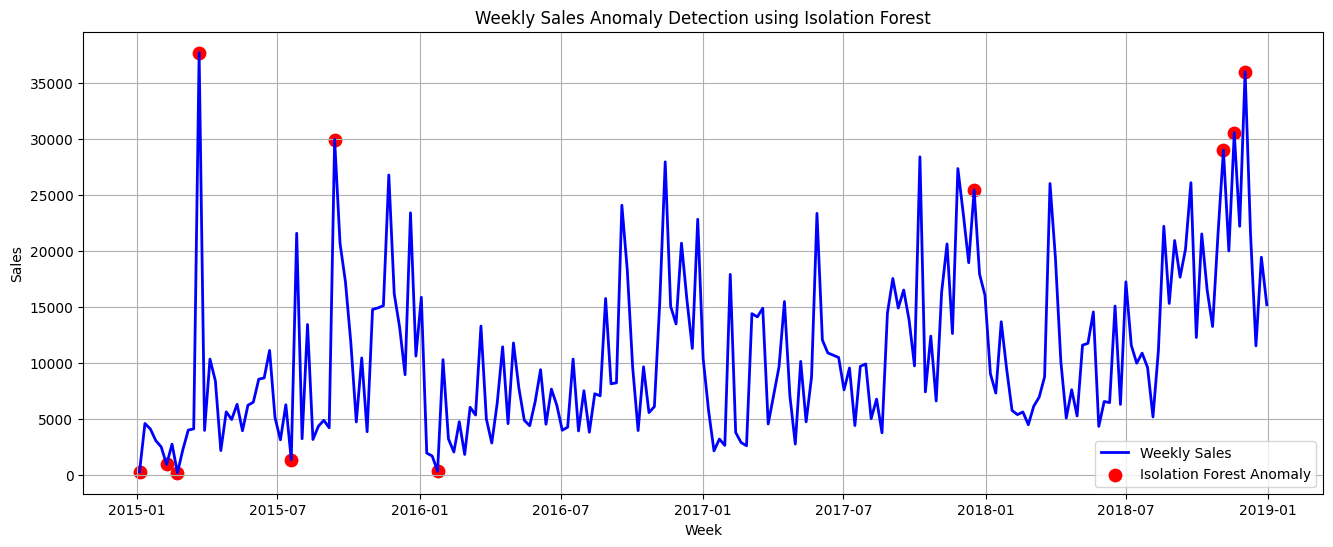

In [ ]:
#Plot Isolation Forest Anomalies
# Create a new figure
plt.figure(figsize=(16,6))

# Plot weekly sales trend
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="blue",
    linewidth=2,
    label="Weekly Sales"
)

# Extract only anomaly weeks
anomaly = weekly_sales[weekly_sales["IF_Anomaly"] == 1]

# Plot anomalies as red points
plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    marker="o",
    s=80,
    label="Isolation Forest Anomaly"
)

# Add title and axis labels
plt.title("Weekly Sales Anomaly Detection using Isolation Forest")
plt.xlabel("Week")
plt.ylabel("Sales")

# Display legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
#Rolling Z-Score Detection
# Define rolling window size (8 weeks)
window = 8

# Calculate rolling average sales
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .mean()
)

# Calculate rolling standard deviation
weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .std()
)

# Compute rolling Z-score
weekly_sales["Z Score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)

# Mark observations with |Z| > 2 as anomalies
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z Score"].abs() > 2
).astype(int)

# Print total anomalies detected
print("Z-Score detected",
      weekly_sales["Z_Anomaly"].sum(),
      "anomalies.")

Z-Score detected 6 anomalies.


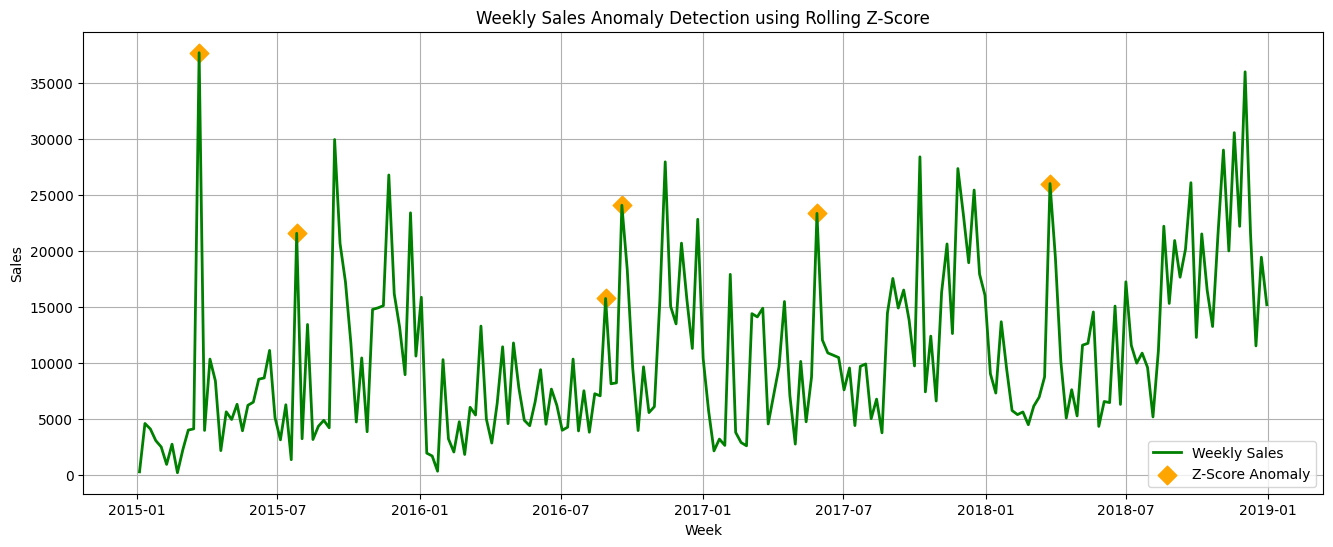

In [ ]:
#Plot Z-Score Anomalies
# Create figure
plt.figure(figsize=(16,6))

# Plot weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    color="green",
    label="Weekly Sales"
)

# Extract anomaly weeks
z = weekly_sales[weekly_sales["Z_Anomaly"] == 1]

# Highlight anomalies using orange diamonds
plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="orange",
    marker="D",
    s=90,
    label="Z-Score Anomaly"
)

# Add labels and title
plt.title("Weekly Sales Anomaly Detection using Rolling Z-Score")
plt.xlabel("Week")
plt.ylabel("Sales")

# Display legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
# Create a comparison table
comparison = weekly_sales[
    ["Order Date", "Sales", "IF_Anomaly", "Z_Anomaly"]
]

# Display all detected anomalies
print(comparison[
    (comparison["IF_Anomaly"] == 1) |
    (comparison["Z_Anomaly"] == 1)
])

# Count anomalies detected by both methods
same = (
    (comparison["IF_Anomaly"] == 1) &
    (comparison["Z_Anomaly"] == 1)
).sum()

# Count anomalies detected only by Isolation Forest
if_only = (
    (comparison["IF_Anomaly"] == 1) &
    (comparison["Z_Anomaly"] == 0)
).sum()

# Count anomalies detected only by Z-Score
z_only = (
    (comparison["IF_Anomaly"] == 0) &
    (comparison["Z_Anomaly"] == 1)
).sum()

# Print comparison summary
print("\nComparison Summary")
print("-------------------")
print("Detected by both methods :", same)
print("Only Isolation Forest :", if_only)
print("Only Z-Score :", z_only)

    Order Date      Sales  IF_Anomaly  Z_Anomaly
0   2015-01-04    304.508           1          0
5   2015-02-08    968.534           1          0
7   2015-02-22    224.912           1          0
11  2015-03-22  37703.665           1          1
28  2015-07-19   1387.686           1          0
29  2015-07-26  21590.080           0          1
36  2015-09-13  29959.137           1          0
55  2016-01-24    358.522           1          0
86  2016-08-28  15773.478           0          1
89  2016-09-18  24095.960           0          1
125 2017-05-28  23367.662           0          1
154 2017-12-17  25449.800           1          0
168 2018-03-25  26029.904           0          1
200 2018-11-04  29017.467           1          0
202 2018-11-18  30572.447           1          0
204 2018-12-02  35998.900           1          0

Comparison Summary
-------------------
Detected by both methods : 1
Only Isolation Forest : 10
Only Z-Score : 5


In [ ]:
# Print heading
print("========== Possible Real-World Explanations ==========\n")

# Select all detected anomalies
anomalies = comparison[
    (comparison["IF_Anomaly"] == 1) |
    (comparison["Z_Anomaly"] == 1)
]

# Loop through each anomaly
for _, row in anomalies.iterrows():

    date = row["Order Date"].strftime("%Y-%m-%d")
    sale = row["Sales"]
    month = row["Order Date"].month

    # Determine whether the anomaly is unusually high or low
    if sale > weekly_sales["Sales"].mean():

        if month in [10, 11, 12]:
            reason = "Likely festive season sales such as Diwali, Black Friday, or Christmas."

        elif month in [6, 7]:
            reason = "Possible seasonal promotion or mid-year discount campaign."

        else:
            reason = "Possible flash sale, marketing campaign, or bulk customer purchase."

    else:
        reason = "Possible stock shortage, supply chain disruption, holidays, or reduced customer demand."

    # Print anomaly details
    print(f"Week: {date}")
    print(f"Sales: {sale:.2f}")
    print("Possible Reason:", reason)
    print("-" * 60)

========== Possible Real-World Explanations ==========

Week: 2015-01-04
Sales: 304.51
Possible Reason: Possible stock shortage, supply chain disruption, holidays, or reduced customer demand.
------------------------------------------------------------
Week: 2015-02-08
Sales: 968.53
Possible Reason: Possible stock shortage, supply chain disruption, holidays, or reduced customer demand.
------------------------------------------------------------
Week: 2015-02-22
Sales: 224.91
Possible Reason: Possible stock shortage, supply chain disruption, holidays, or reduced customer demand.
------------------------------------------------------------
Week: 2015-03-22
Sales: 37703.67
Possible Reason: Possible flash sale, marketing campaign, or bulk customer purchase.
------------------------------------------------------------
Week: 2015-07-19
Sales: 1387.69
Possible Reason: Possible stock shortage, supply chain disruption, holidays, or reduced customer demand.
-------------------------------------

In [ ]:
# Comparison of Isolation Forest and Rolling Z-Score Results

print("===== Comparison of Anomaly Detection Methods =====\n")

print("Detected by both methods :", same)
print("Only Isolation Forest    :", if_only)
print("Only Z-Score             :", z_only)

print("\nInterpretation:")
print(
    "Only one anomaly was detected by both methods, indicating strong "
    "agreement for that particular sales week."
)

print(
    "Isolation Forest detected 10 additional anomalies that were not "
    "identified by the Rolling Z-Score method. This is because Isolation "
    "Forest analyzes the overall data distribution and can detect complex "
    "or non-linear abnormal patterns."
)

print(
    "The Rolling Z-Score method detected 5 unique anomalies based on "
    "sales values deviating more than two standard deviations from the "
    "rolling mean. It is more sensitive to sudden statistical changes "
    "in recent sales trends."
)

print("\nConclusion:")
print(
    "The two methods do not completely agree, which indicates that they "
    "capture different types of anomalies. Isolation Forest is better at "
    "identifying unusual patterns in the overall dataset, while the "
    "Rolling Z-Score focuses on significant deviations from local trends. "
    "Using both methods together provides a more comprehensive and reliable "
    "approach to anomaly detection in retail sales data."
)

===== Comparison of Anomaly Detection Methods =====

Detected by both methods : 1
Only Isolation Forest    : 10
Only Z-Score             : 5

Interpretation:
Only one anomaly was detected by both methods, indicating strong agreement for that particular sales week.
Isolation Forest detected 10 additional anomalies that were not identified by the Rolling Z-Score method. This is because Isolation Forest analyzes the overall data distribution and can detect complex or non-linear abnormal patterns.
The Rolling Z-Score method detected 5 unique anomalies based on sales values deviating more than two standard deviations from the rolling mean. It is more sensitive to sudden statistical changes in recent sales trends.

Conclusion:
The two methods do not completely agree, which indicates that they capture different types of anomalies. Isolation Forest is better at identifying unusual patterns in the overall dataset, while the Rolling Z-Score focuses on significant deviations from local trends. Us

**Comparison:** The two anomaly detection methods do not completely agree. Only 1 sales week was identified as anomalous by both methods. Isolation Forest detected 10 additional anomalies, whereas the Rolling Z-Score method detected 5 additional anomalies. This difference indicates that Isolation Forest captures complex and non-linear abnormal patterns by considering the overall data distribution, while the Rolling Z-Score identifies weeks with significant deviations from the local rolling average. Therefore, using both methods together provides a more comprehensive and reliable anomaly detection framework for retail sales forecasting.

In [ ]:
#Task 6 — Product Demand Segmentation using Clustering
# Import required libraries
import pandas as pd
import numpy as np

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract year and month
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")

# Monthly sales for each sub-category
monthly = (
    df.groupby(["Sub-Category","Month"])["Sales"]
    .sum()
    .reset_index()
)

# Total Sales Volume
total_sales = (
    monthly.groupby("Sub-Category")["Sales"]
    .sum()
)

# Sales Volatility
volatility = (
    monthly.groupby("Sub-Category")["Sales"]
    .std()
)

# Average Order Value
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

# Yearly sales
yearly = (
    df.groupby(["Sub-Category","Year"])["Sales"]
    .sum()
    .reset_index()
)

# Calculate Year-over-Year Growth
growth = yearly.pivot(index="Sub-Category",
                      columns="Year",
                      values="Sales")

growth = growth.fillna(0)

years = growth.columns.tolist()

if len(years) >= 2:
    growth_rate = (
        (growth[years[-1]]-growth[years[-2]])
        /(growth[years[-2]]+1)
    )*100
else:
    growth_rate = pd.Series(
        0,
        index=growth.index
    )

# Create feature dataset
features = pd.DataFrame({
    "Total Sales": total_sales,
    "Growth Rate": growth_rate,
    "Volatility": volatility,
    "Average Order Value": avg_order
})

features = features.fillna(0)

features.head()

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,39.547302,2579.994809,217.178175
Appliances,104618.4030,54.562423,1821.621539,227.926804
Art,26705.4100,49.817028,330.488343,34.019631
Binders,200028.7850,46.385342,3848.223648,134.067550
Bookcases,113813.1987,14.266809,2220.405080,503.598224


In [ ]:
# Import scaler
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

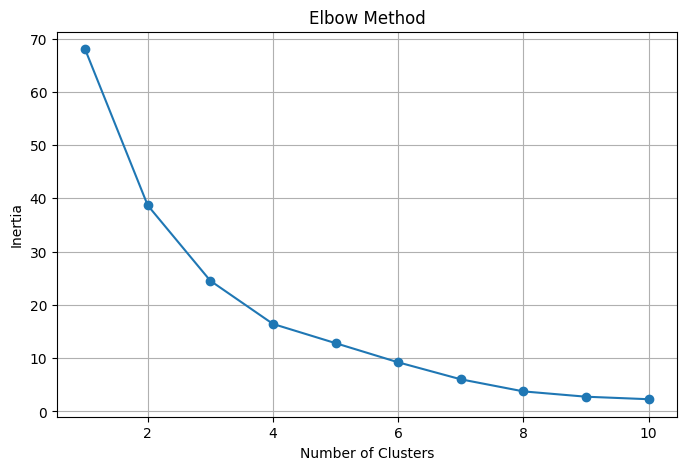

In [ ]:
# Import KMeans
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different values of K
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [ ]:
# Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

features.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,39.547302,2579.994809,217.178175,1
Appliances,104618.4030,54.562423,1821.621539,227.926804,0
Art,26705.4100,49.817028,330.488343,34.019631,0
Binders,200028.7850,46.385342,3848.223648,134.067550,1
Bookcases,113813.1987,14.266809,2220.405080,503.598224,3


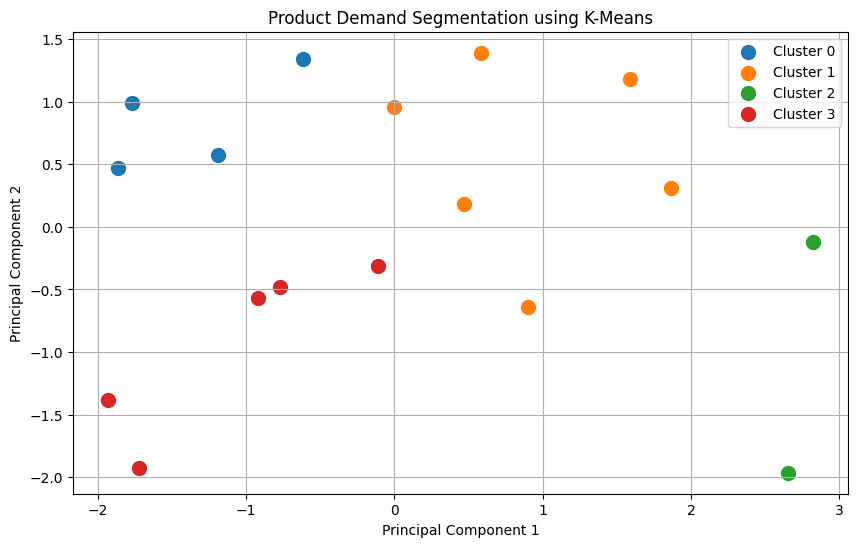

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Reduce dimensions to 2
pca = PCA(n_components=2)

components = pca.fit_transform(
    scaled_features
)

# Store PCA components
features["PCA1"] = components[:,0]
features["PCA2"] = components[:,1]

# Plot clusters
plt.figure(figsize=(10,6))

for cluster in sorted(features["Cluster"].unique()):

    subset = features[
        features["Cluster"]==cluster
    ]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=100,
        label=f"Cluster {cluster}"
    )

# Label axes
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Product Demand Segmentation using K-Means")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Display average characteristics of each cluster
summary = features.groupby("Cluster").mean()

print(summary)

           Total Sales  Growth Rate   Volatility  Average Order Value  \
Cluster                                                                 
0         55124.960750    44.338399   850.101520            88.488540   
1        239495.780667    24.994859  3489.056075           361.131228   
2        167743.362500     6.841087  5552.164569          1930.716763   
3         53715.106140    -0.495069  1176.495600           186.153333   

             PCA1      PCA2  
Cluster                      
0       -1.358837  0.843860  
1        0.900991  0.562908  
2        2.739199 -1.040575  
3       -1.089800 -0.934347  


In [ ]:
# Assign meaningful names
cluster_labels = {
    0:"High Volume, Stable Demand",
    1:"Low Volume, High Volatility",
    2:"Growing Demand",
    3:"Declining Demand"
}

features["Demand Segment"] = (
    features["Cluster"]
    .map(cluster_labels)
)

print(features[
    ["Demand Segment"]
].value_counts())

Demand Segment             
Low Volume, High Volatility    6
Declining Demand               5
High Volume, Stable Demand     4
Growing Demand                 2
Name: count, dtype: int64


In [ ]:
# Print stocking strategy for each demand segment
print("========== Stocking Strategy ==========\n")

strategies = {

"High Volume, Stable Demand":
"Maintain high inventory levels with regular replenishment because demand is consistent and predictable.",

"Low Volume, High Volatility":
"Keep limited safety stock and monitor demand frequently to avoid overstocking.",

"Growing Demand":
"Increase inventory gradually and prepare for higher future demand through proactive replenishment.",

"Declining Demand":
"Reduce inventory levels, avoid excessive purchasing, and focus on clearance or promotional sales."

}

for segment in features["Demand Segment"].unique():

    print(segment)

    print("Recommendation:")

    print(strategies[segment])

    print("-"*60)

========== Stocking Strategy ==========

Low Volume, High Volatility
Recommendation:
Keep limited safety stock and monitor demand frequently to avoid overstocking.
------------------------------------------------------------
High Volume, Stable Demand
Recommendation:
Maintain high inventory levels with regular replenishment because demand is consistent and predictable.
------------------------------------------------------------
Declining Demand
Recommendation:
Reduce inventory levels, avoid excessive purchasing, and focus on clearance or promotional sales.
------------------------------------------------------------
Growing Demand
Recommendation:
Increase inventory gradually and prepare for higher future demand through proactive replenishment.
------------------------------------------------------------
